## Code to show the number of datasets per Organ + AS, by sex and CTann tool

## Install and import libraries

In [6]:
%pip install pandas seaborn matplotlib requests


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import requests
import io


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


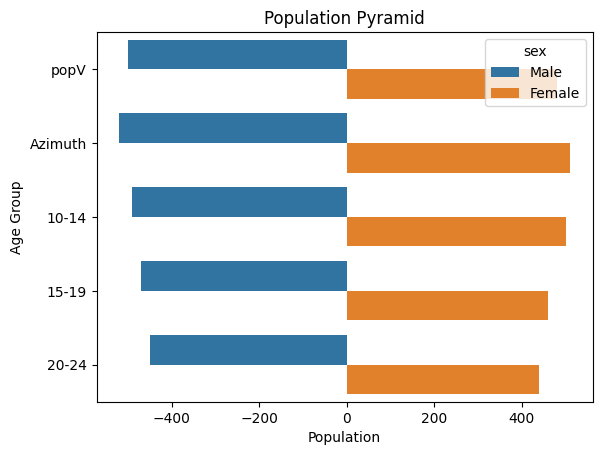

,age_group,sex,population
0,popV,Male,-500
1,Azimuth,Male,-520
2,10-14,Male,-490
3,15-19,Male,-470
4,20-24,Male,-450
5,popV,Female,480
6,Azimuth,Female,510
7,10-14,Female,500
8,15-19,Female,460
9,20-24,Female,440


In [10]:
data = pd.DataFrame(
    {
        "age_group": ["popV", "Azimuth", "10-14", "15-19", "20-24"] * 2,
        "sex": ["Male"] * 5 + ["Female"] * 5,
        "population": [-500, -520, -490, -470, -450, 480, 510, 500, 460, 440],
    }
)

plt.figure()
sns.barplot(data=data, y="age_group", x="population", hue="sex")

plt.title("Population Pyramid")
plt.xlabel("Population")
plt.ylabel("Age Group")
plt.show()
data

In [11]:
# Plotly population-pyramid style for your organ cell data
import io
import pandas as pd
import plotly.graph_objects as go

csv_data = """organ,organ_id,as,as_label,sex,tool,modality,cell_id,cell_label,cell_count,cell_percentage,dataset_count
large intestine,http://purl.obolibrary.org/obo/UBERON_0000059,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_colonocyte,Colonocyte,1.205E0,1.476534738389903E-1,3
large intestine,http://purl.obolibrary.org/obo/UBERON_0000059,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_iga-plasma-cell,IgA plasma cell,1.182E0,1.44835191765715E-1,3
large intestine,http://purl.obolibrary.org/obo/UBERON_0000059,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_best4-epithelial,BEST4+ epithelial,6.990000000000001E-1,8.5651268226933E-2,3
large intestine,http://purl.obolibrary.org/obo/UBERON_0000059,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_activated-cd4-t,Activated CD4 T,6.900000000000001E-1,8.454846219826005E-2,3
large intestine,http://purl.obolibrary.org/obo/UBERON_0000059,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_ta,TA,5.4E-1,6.616836172037743E-2,3
large intestine,http://purl.obolibrary.org/obo/UBERON_0000059,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_memory-b,Memory B,4.25E-1,5.207695135400075E-2,3
large intestine,http://purl.obolibrary.org/obo/UBERON_0000059,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_trgv2-gdt,TRGV2 gdT,2.94E-1,3.602499693664993E-2,3
large intestine,http://purl.obolibrary.org/obo/UBERON_0000059,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_activated-cd8-t,Activated CD8 T,2.52E-1,3.08785688028428E-2,3
large intestine,http://purl.obolibrary.org/obo/UBERON_0000059,http://purl.org/ccf/ASCTB-TEMP_transitional-stromal-3-c3-,Transitional Stromal 3 (C3+),2.41E-1,2.953069476779807E-2,3
large intestine,http://purl.obolibrary.org/obo/UBERON_0000059,http://purl.org/ccf/ASCTB-TEMP_tfh,Tfh,1.76E-1,2.156598456071561E-2,3
large intestine,http://purl.obolibrary.org/obo/UBERON_0000059,http://purl.org/ccf/ASCTB-TEMP_macrophages,Macrophages,1.61E-1,1.972797451292734E-2,3
large intestine,http://purl.org/ccf/ASCTB-TEMP_best2-goblet-cell,BEST2+ Goblet cell,1.54E-1,1.887023649062615E-2,3
large intestine,http://purl.org/ccf/ASCTB-TEMP_trgv4-gdt,TRGV4 gdT,1.45E-1,1.77674304619532E-2,3
large intestine,http://purl.org/ccf/ASCTB-TEMP_cd8-tmem,CD8 Tmem,1.35E-1,1.654209043009436E-2,3
"""  # <-- if your CSV was truncated, paste the remainder here

# read into DataFrame; be forgiving about malformed rows
df = pd.read_csv(
    io.StringIO(csv_data), dtype=str, skip_blank_lines=True, keep_default_na=False
)

# ensure numeric and fill missing sexes/cell_label if necessary
df["cell_count"] = pd.to_numeric(df["cell_count"], errors="coerce").fillna(0.0)
df["sex"] = df["sex"].replace("", "Unknown")

# aggregate by cell_label and sex
agg = (
    df.groupby(["cell_label", "sex"], dropna=False)["cell_count"]
    .sum()
    .unstack(fill_value=0.0)
)

# ensure both sexes (Male/Female) exist as columns
for col in ["Male", "Female"]:
    if col not in agg.columns:
        agg[col] = 0.0

# compute total and sort by total descending
agg["total"] = agg["Male"].abs() + agg["Female"].abs()
agg = agg.sort_values(
    "total", ascending=True
)  # small at top for nicer vertical ordering

y = agg.index.tolist()
male_vals = -agg["Male"].values  # negative to plot left
female_vals = agg["Female"].values

fig = go.Figure()
fig.add_trace(
    go.Bar(
        y=y,
        x=male_vals,
        name="Male",
        orientation="h",
        hovertemplate="%{y}: %{x}<extra></extra>",
    )
)
fig.add_trace(
    go.Bar(
        y=y,
        x=female_vals,
        name="Female",
        orientation="h",
        hovertemplate="%{y}: %{x}<extra></extra>",
    )
)

fig.update_layout(
    title="Cell-type distribution by Sex (population-pyramid style)",
    barmode="relative",
    xaxis=dict(title="cell_count", tickformat=".2f"),
    yaxis=dict(title="cell_label"),
    legend=dict(x=0.75, y=1.1),
    template="plotly_white",
    height=700,
)

fig.update_yaxes(autorange="reversed")  # youngest/top-first style; optional
fig.show()


## Visualize

In [15]:
import plotly.graph_objects as go

age_groups = ["0-4", "5-9", "10-14", "15-19", "20-24"]
males = [-500, -520, -490, -470, -450]  # negative for left side
females = [480, 510, 500, 460, 440]

fig = go.Figure()

fig.add_trace(go.Bar(y=age_groups, x=males, name="Males", orientation="h"))

fig.add_trace(go.Bar(y=age_groups, x=females, name="Females", orientation="h"))

fig.update_layout(
    title="Population Pyramid",
    barmode="overlay",
    xaxis_title="Population",
    yaxis_title="Age Group",
    template="plotly_white",
)

fig.show()
